# Rademacher Anti-Serum (RAS) Protocol

**Docker image**: `ml4t`

**Book Reference**: Chapter 16, §16.7 — strategy-level overfitting control.

This notebook demonstrates the Rademacher Anti-Serum (RAS) protocol for backtest overfitting detection using `ml4t-diagnostic`.

## Why RAS Over DSR?

| Aspect | DSR | RAS |
|--------|-----|-----|
| Correlation | Ignores strategy correlation | Accounts for correlation |
| Assumption | Strategies independent | Any correlation structure |
| Bound | Conservative (asymptotic) | Tight (distribution-free) |
| Computation | Closed-form | Monte Carlo simulation |

## Key Concepts

- **Rademacher Complexity (R̂)**: Measures overfitting risk from multiple testing
- **Massart's Bound**: √(2 log N / T) - upper bound for uncorrelated strategies
- **RAS Adjustment**: θ ≥ θ̂ - 2R̂ - estimation_error
- **Data Snooping Bias**: Selection bias from picking the "best" strategy

## References

- Paleologo, G. (2024). "Elements of Quantitative Investing", Chapter 8
- Mohri, Rostamizadeh & Talwalkar (2018). "Foundations of Machine Learning"

In [1]:
"""Rademacher Anti-Serum (RAS) Protocol — distribution-free backtest overfitting detection."""

import numpy as np

# Quick test support
# Visualization
import plotly.graph_objects as go

# ml4t-diagnostic RAS functions
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_ic_adjustment,
    ras_sharpe_adjustment,
)
from plotly.subplots import make_subplots
from scipy import stats

import utils  # noqa: F401
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill injects overrides after this cell
N_SIMULATIONS = 5000
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
EULER_MASCHERONI = 0.5772156649

### Deflated Sharpe Ratio Baseline

We include a self-contained DSR helper so we can compare its
output against the RAS adjustment on the same data.

In [5]:
def deflated_sharpe_ratio(
    observed_sharpe: float,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    n_samples: int = 252,
    n_trials: int = 1,
    variance_trials: float = 0.0,
    confidence_level: float = 0.95,
    return_format: str = "probability",
    return_components: bool = False,
) -> float | dict[str, float | bool]:
    """Backward-compatible DSR helper for legacy chapter notebook examples."""
    if n_trials <= 1 or variance_trials <= 0:
        expected_max = 0.0
    else:
        z1 = stats.norm.ppf(1.0 - (1.0 / n_trials))
        z2 = stats.norm.ppf(1.0 - (np.exp(-1.0) / n_trials))
        expected_max = np.sqrt(max(variance_trials, 0.0)) * (
            (1.0 - EULER_MASCHERONI) * z1 + EULER_MASCHERONI * z2
        )

    denom = np.sqrt(
        max(
            1.0 - skewness * observed_sharpe + ((kurtosis - 1.0) / 4.0) * observed_sharpe**2,
            1e-12,
        )
    )
    z_score = ((observed_sharpe - expected_max) * np.sqrt(max(n_samples - 1, 1))) / denom
    probability = float(stats.norm.cdf(z_score))
    p_value = float(1.0 - probability)
    adjusted_sharpe = float(observed_sharpe - expected_max)

    if return_components:
        return {
            "dsr": probability,
            "z_score": float(z_score),
            "p_value": p_value,
            "expected_max_sharpe": float(expected_max),
            "adjusted_sharpe": adjusted_sharpe,
            "is_significant": probability >= confidence_level,
        }

    if return_format == "probability":
        return probability
    if return_format == "zscore":
        return float(z_score)
    if return_format == "adjusted_sharpe":
        return adjusted_sharpe
    if return_format == "p_value":
        return p_value
    raise ValueError(f"Unknown return_format: {return_format}")

### Library Equivalence Check

The DSR helper above mirrors the algebra section by section. Production
code calls `ml4t-diagnostic` directly. Quick verification:

In [6]:
from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio_from_statistics

_local = deflated_sharpe_ratio(
    observed_sharpe=1.0,
    skewness=0.0,
    kurtosis=3.0,
    n_samples=504,
    n_trials=100,
    variance_trials=0.3,
    return_format="probability",
)
_lib = deflated_sharpe_ratio_from_statistics(
    observed_sharpe=1.0 / np.sqrt(252),
    n_samples=504,
    n_trials=100,
    variance_trials=0.3 / 252,
    skewness=0.0,
    excess_kurtosis=0.0,
)
print(f"Local DSR: {_local:.4f} | Library DSR: {_lib.probability:.4f}")
print("In practice, use: from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio")

Local DSR: 0.0000 | Library DSR: 0.1022
In practice, use: from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio


## 1. Understanding Rademacher Complexity

Rademacher complexity measures how well a set of strategies can fit random noise:

$$\hat{R} = \mathbb{E}_\epsilon\left[\max_n \frac{\epsilon^T x^n}{T}\right]$$

Where $\epsilon$ is a Rademacher vector (random ±1 with probability 0.5).

In [7]:
# Illustrate Rademacher complexity
np.random.seed(42)

T = 252  # 1 year daily
N = 100  # 100 strategies

# Case 1: Uncorrelated strategies
X_uncorrelated = np.random.randn(T, N)

# Case 2: Highly correlated strategies (parameter variants)
base_strategy = np.random.randn(T)
X_correlated = np.column_stack([base_strategy + np.random.randn(T) * 0.1 for _ in range(N)])

# Case 3: Identical strategies
X_identical = np.column_stack([base_strategy for _ in range(N)])

# Compute Rademacher complexity
R_uncorrelated = rademacher_complexity(X_uncorrelated, n_simulations=10000, random_state=42)
R_correlated = rademacher_complexity(X_correlated, n_simulations=10000, random_state=42)
R_identical = rademacher_complexity(X_identical, n_simulations=10000, random_state=42)

# Massart's bound (theoretical maximum for uncorrelated)
massart_bound = np.sqrt(2 * np.log(N) / T)

print("=== Rademacher Complexity Analysis ===")
print(f"\nNumber of strategies: {N}")
print(f"Sample size: {T}")
print(f"\nMassart's bound (uncorrelated): {massart_bound:.4f}")
print("\nEmpirical R̂:")
print(f"  Uncorrelated: {R_uncorrelated:.4f} ({R_uncorrelated / massart_bound:.1%} of bound)")
print(f"  Correlated:   {R_correlated:.4f} ({R_correlated / massart_bound:.1%} of bound)")
print(f"  Identical:    {R_identical:.4f} ({R_identical / massart_bound:.1%} of bound)")

=== Rademacher Complexity Analysis ===

Number of strategies: 100
Sample size: 252

Massart's bound (uncorrelated): 0.1912

Empirical R̂:
  Uncorrelated: 0.1581 (82.7% of bound)
  Correlated:   0.0154 (8.0% of bound)
  Identical:    -0.0005 (-0.3% of bound)


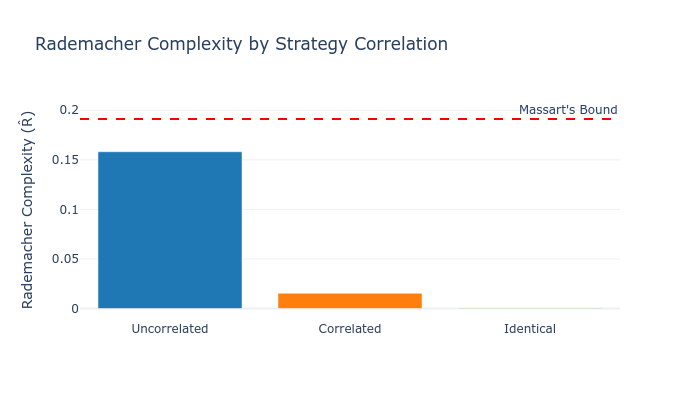


Key Insight: Correlated strategies have LOWER overfitting risk!
Testing many parameter variants is less risky than testing truly independent strategies.


In [8]:
# Visualize correlation impact
fig = go.Figure()

strategies = ["Uncorrelated", "Correlated", "Identical"]
R_values = [R_uncorrelated, R_correlated, R_identical]

fig.add_trace(
    go.Bar(x=strategies, y=R_values, marker_color=["#1f77b4", "#ff7f0e", "#2ca02c"], name="R̂")
)

fig.add_hline(
    y=massart_bound, line_dash="dash", line_color="red", annotation_text="Massart's Bound"
)

fig.update_layout(
    title="Rademacher Complexity by Strategy Correlation",
    yaxis_title="Rademacher Complexity (R̂)",
    template="plotly_white",
    height=400,
)

fig.show()

print("\nKey Insight: Correlated strategies have LOWER overfitting risk!")
print("Testing many parameter variants is less risky than testing truly independent strategies.")

## 2. RAS Adjustment for Sharpe Ratios

Formula (Procedure 8.2 in Paleologo):

$$\theta_n \geq \hat{\theta}_n - 2\hat{R} - 3\sqrt{\frac{2\log(2/\delta)}{T}} - \sqrt{\frac{2\log(2N/\delta)}{T}}$$

In [9]:
# Simulate backtesting many strategies
np.random.seed(42)

T = 504  # 2 years
N = 500  # 500 strategy variants

# Generate returns matrix
# Strategies are correlated (parameter sweep of similar strategy)
base_returns = np.random.randn(T) * 0.01 + 0.0002  # Slight alpha
strategy_returns = np.column_stack([base_returns + np.random.randn(T) * 0.005 for _ in range(N)])

# Calculate Sharpe ratios (annualized)
observed_sharpe = (
    np.mean(strategy_returns, axis=0) / np.std(strategy_returns, axis=0, ddof=1) * np.sqrt(252)
)

# Z-score for Rademacher complexity
X = (strategy_returns - np.mean(strategy_returns, axis=0)) / np.std(
    strategy_returns, axis=0, ddof=1
)

print("=== Strategy Universe ===")
print(f"\nStrategies: {N}")
print(f"Sample size: {T} days")
print("\nObserved Sharpe Ratios:")
print(f"  Max: {np.max(observed_sharpe):.3f}")
print(f"  Mean: {np.mean(observed_sharpe):.3f}")
print(f"  Min: {np.min(observed_sharpe):.3f}")

=== Strategy Universe ===

Strategies: 500
Sample size: 504 days

Observed Sharpe Ratios:
  Max: 1.230
  Mean: 0.442
  Min: -0.513


In [10]:
# Compute Rademacher complexity
R_hat = rademacher_complexity(X, n_simulations=10000, random_state=42)

print("\n=== Rademacher Analysis ===")
print(f"\nR̂: {R_hat:.4f}")
print(f"Massart's bound: {np.sqrt(2 * np.log(N) / T):.4f}")
print(f"Ratio: {R_hat / np.sqrt(2 * np.log(N) / T):.1%}")


=== Rademacher Analysis ===

R̂: 0.0606
Massart's bound: 0.1570
Ratio: 38.6%


In [11]:
# Apply RAS adjustment
adjusted_sharpe = ras_sharpe_adjustment(
    observed_sharpe=observed_sharpe,
    complexity=R_hat,
    n_samples=T,
    n_strategies=N,
    delta=0.05,  # 95% confidence
)

# Count significant strategies
n_significant_raw = np.sum(observed_sharpe > 0)
n_significant_ras = np.sum(adjusted_sharpe > 0)

print("\n=== RAS Adjustment Results ===")
print("\nSignificance threshold: SR > 0")
print("\nSignificant strategies:")
print(f"  Before RAS: {n_significant_raw}/{N} ({n_significant_raw / N:.1%})")
print(f"  After RAS:  {n_significant_ras}/{N} ({n_significant_ras / N:.1%})")
print(f"\nRejection rate: {(n_significant_raw - n_significant_ras) / n_significant_raw:.1%}")

print("\nBest strategy:")
best_idx = np.argmax(observed_sharpe)
print(f"  Observed SR: {observed_sharpe[best_idx]:.3f}")
print(f"  Adjusted SR: {adjusted_sharpe[best_idx]:.3f}")
print(f"  Adjustment: {observed_sharpe[best_idx] - adjusted_sharpe[best_idx]:.3f}")


=== RAS Adjustment Results ===

Significance threshold: SR > 0

Significant strategies:
  Before RAS: 463/500 (92.6%)
  After RAS:  113/500 (22.6%)

Rejection rate: 75.6%

Best strategy:
  Observed SR: 1.230
  Adjusted SR: 0.547
  Adjustment: 0.682


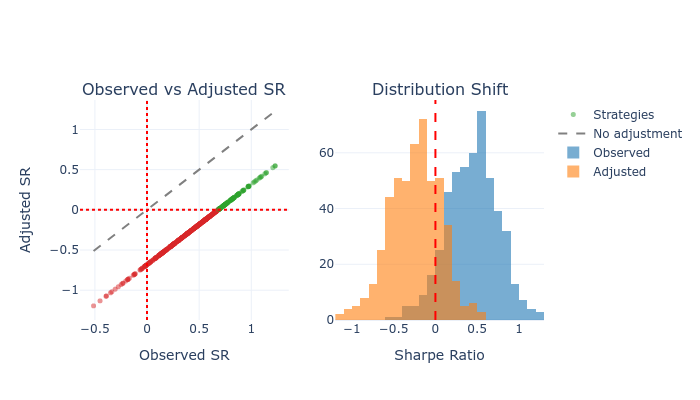

In [12]:
# Visualize RAS adjustment
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Observed vs Adjusted SR", "Distribution Shift"]
)

# Scatter plot
fig.add_trace(
    go.Scatter(
        x=observed_sharpe,
        y=adjusted_sharpe,
        mode="markers",
        marker=dict(size=5, color=np.where(adjusted_sharpe > 0, "#2ca02c", "#d62728"), opacity=0.5),
        name="Strategies",
    ),
    row=1,
    col=1,
)

# 45-degree line
sr_range = [np.min(observed_sharpe), np.max(observed_sharpe)]
fig.add_trace(
    go.Scatter(
        x=sr_range,
        y=sr_range,
        mode="lines",
        line=dict(dash="dash", color="gray"),
        name="No adjustment",
    ),
    row=1,
    col=1,
)

# Zero lines
fig.add_hline(y=0, line_dash="dot", line_color="red", row=1, col=1)
fig.add_vline(x=0, line_dash="dot", line_color="red", row=1, col=1)

# Distribution comparison
fig.add_trace(
    go.Histogram(
        x=observed_sharpe, name="Observed", marker_color="#1f77b4", opacity=0.6, nbinsx=30
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Histogram(
        x=adjusted_sharpe, name="Adjusted", marker_color="#ff7f0e", opacity=0.6, nbinsx=30
    ),
    row=1,
    col=2,
)

fig.add_vline(x=0, line_dash="dash", line_color="red", row=1, col=2)

fig.update_layout(height=400, template="plotly_white", barmode="overlay")
fig.update_xaxes(title_text="Observed SR", row=1, col=1)
fig.update_yaxes(title_text="Adjusted SR", row=1, col=1)
fig.update_xaxes(title_text="Sharpe Ratio", row=1, col=2)

fig.show()

## 3. RAS vs DSR Comparison

Compare the two multiple testing corrections.

In [13]:
# Compare RAS and DSR
best_sharpe = np.max(observed_sharpe)
variance_trials = np.var(observed_sharpe, ddof=1)

# DSR analysis
dsr_result = deflated_sharpe_ratio(
    observed_sharpe=best_sharpe,
    n_trials=N,
    variance_trials=variance_trials,
    n_samples=T,
    return_components=True,
)

# RAS analysis (best strategy)
ras_adjusted_best = adjusted_sharpe[best_idx]

print("=== RAS vs DSR Comparison ===")
print(f"\nBest observed Sharpe: {best_sharpe:.3f}")
print("\nDSR Analysis:")
print(f"  Expected max (E[max]): {dsr_result['expected_max_sharpe']:.3f}")
print(f"  DSR probability: {dsr_result['dsr']:.3f}")
print(f"  p-value: {dsr_result['p_value']:.4f}")

print("\nRAS Analysis:")
print(f"  Rademacher complexity: {R_hat:.4f}")
print(f"  Adjusted SR: {ras_adjusted_best:.3f}")
print(f"  Adjustment magnitude: {best_sharpe - ras_adjusted_best:.3f}")
print(f"  Significant at 95%: {'Yes' if ras_adjusted_best > 0 else 'No'}")

=== RAS vs DSR Comparison ===

Best observed Sharpe: 1.230

DSR Analysis:
  Expected max (E[max]): 0.926
  DSR probability: 1.000
  p-value: 0.0000

RAS Analysis:
  Rademacher complexity: 0.0606
  Adjusted SR: 0.547
  Adjustment magnitude: 0.682
  Significant at 95%: Yes


## 4. RAS for Information Coefficients

In [14]:
# Simulate multiple signals with varying IC
np.random.seed(123)

T = 252  # 1 year
N = 50  # 50 signals

# Generate IC matrix (T observations, N signals)
# Most signals are noise, a few have true predictive power
n_true = 5
true_ic = 0.03  # True IC for real signals

ic_matrix = np.random.randn(T, N) * 0.1  # Cross-sectional IC noise
ic_matrix[:, :n_true] += true_ic  # Add true IC to first 5

observed_ic = np.mean(ic_matrix, axis=0)

print("=== Signal IC Analysis ===")
print(f"\nSignals: {N}")
print(f"True signals: {n_true}")
print(f"True IC: {true_ic}")
print("\nObserved mean IC:")
print(f"  Max: {np.max(observed_ic):.4f}")
print(f"  Mean: {np.mean(observed_ic):.4f}")

=== Signal IC Analysis ===

Signals: 50
True signals: 5
True IC: 0.03

Observed mean IC:
  Max: 0.0400
  Mean: 0.0045


In [15]:
# Compute Rademacher complexity for IC
# Normalize IC matrix
X_ic = ic_matrix / 0.1  # Normalize by typical IC range

R_hat_ic = rademacher_complexity(X_ic, n_simulations=10000, random_state=42)

# Apply RAS adjustment for IC
adjusted_ic = ras_ic_adjustment(
    observed_ic=observed_ic,
    complexity=R_hat_ic,
    n_samples=T,
    delta=0.05,
    kappa=0.1,  # Max IC bound
)

# Count significant signals
n_sig_raw = np.sum(observed_ic > 0.01)  # IC > 1% threshold
n_sig_ras = np.sum(adjusted_ic > 0.01)

print("\n=== RAS Adjustment for IC ===")
print(f"\nR̂ (IC): {R_hat_ic:.4f}")
print("\nSignificant signals (IC > 1%):")
print(f"  Before RAS: {n_sig_raw}/{N}")
print(f"  After RAS:  {n_sig_ras}/{N}")

# Check true signal detection
true_detected_raw = np.sum(observed_ic[:n_true] > 0.01)
true_detected_ras = np.sum(adjusted_ic[:n_true] > 0.01)
false_positives_raw = np.sum(observed_ic[n_true:] > 0.01)
false_positives_ras = np.sum(adjusted_ic[n_true:] > 0.01)

print("\nTrue signal detection:")
print(f"  Raw: {true_detected_raw}/{n_true}")
print(f"  RAS: {true_detected_ras}/{n_true}")
print("\nFalse positives:")
print(f"  Raw: {false_positives_raw}/{N - n_true}")
print(f"  RAS: {false_positives_ras}/{N - n_true}")


=== RAS Adjustment for IC ===

R̂ (IC): 0.1423

Significant signals (IC > 1%):
  Before RAS: 10/50
  After RAS:  0/50

True signal detection:
  Raw: 5/5
  RAS: 0/5

False positives:
  Raw: 5/45
  RAS: 0/45


## 5. Case Study: ETF Rotational Strategy

Apply RAS to a parameter sweep of momentum strategies.

In [16]:
# Simulate parameter sweep for momentum strategy
np.random.seed(42)

T = 504  # 2 years daily

# Parameter grid
lookback_periods = [5, 10, 21, 42, 63, 126, 252]
holding_periods = [1, 5, 10, 21, 42]
n_top_assets = [1, 2, 3, 5]

N = len(lookback_periods) * len(holding_periods) * len(n_top_assets)
print(f"Parameter combinations: {N}")

# Generate correlated strategy returns
# Base momentum strategy has slight edge
base_returns = np.random.randn(T) * 0.01 + 0.0001

strategy_returns = []
param_labels = []

for lb in lookback_periods:
    for hp in holding_periods:
        for top_n in n_top_assets:
            # Parameter affects returns slightly
            param_noise = np.random.randn(T) * 0.003
            returns = base_returns + param_noise
            strategy_returns.append(returns)
            param_labels.append(f"LB{lb}_HP{hp}_N{top_n}")

strategy_returns = np.column_stack(strategy_returns)

# Calculate Sharpe ratios
sharpe_ratios = (
    np.mean(strategy_returns, axis=0) / np.std(strategy_returns, axis=0, ddof=1) * np.sqrt(252)
)

Parameter combinations: 140


In [17]:
# Apply RAS
X_etf = (strategy_returns - np.mean(strategy_returns, axis=0)) / np.std(
    strategy_returns, axis=0, ddof=1
)
R_hat_etf = rademacher_complexity(X_etf, n_simulations=10000, random_state=42)

adjusted_sharpe_etf = ras_sharpe_adjustment(
    observed_sharpe=sharpe_ratios, complexity=R_hat_etf, n_samples=T, n_strategies=N, delta=0.05
)

print("=== ETF Momentum Parameter Sweep ===")
print(f"\nStrategies tested: {N}")
print(f"R̂: {R_hat_etf:.4f}")
print(f"Massart's bound: {np.sqrt(2 * np.log(N) / T):.4f}")

# Best strategy
best_idx = np.argmax(sharpe_ratios)
print(f"\nBest parameters: {param_labels[best_idx]}")
print(f"  Observed SR: {sharpe_ratios[best_idx]:.3f}")
print(f"  Adjusted SR: {adjusted_sharpe_etf[best_idx]:.3f}")

# Significance
n_sig_raw = np.sum(sharpe_ratios > 0.5)
n_sig_ras = np.sum(adjusted_sharpe_etf > 0.5)
print("\nStrategies with SR > 0.5:")
print(f"  Before RAS: {n_sig_raw}")
print(f"  After RAS: {n_sig_ras}")

=== ETF Momentum Parameter Sweep ===

Strategies tested: 140
R̂: 0.0336
Massart's bound: 0.1400

Best parameters: LB126_HP42_N2
  Observed SR: 0.830
  Adjusted SR: 0.215

Strategies with SR > 0.5:
  Before RAS: 25
  After RAS: 0


## 6. Case Study: Crypto Funding Strategy

In [18]:
# Simulate crypto parameter sweep
np.random.seed(789)

T = 24 * 90  # 90 days hourly

# Parameter grid for funding rate strategy
lookback_hours = [4, 8, 24, 48, 72]
threshold_pcts = [0.01, 0.02, 0.05, 0.1]
position_sizes = [0.25, 0.5, 0.75, 1.0]

N = len(lookback_hours) * len(threshold_pcts) * len(position_sizes)
print(f"Crypto strategy variants: {N}")

# Generate hourly returns
base_returns = np.random.randn(T) * 0.002 + 0.00005  # Slight alpha

crypto_returns = np.column_stack([base_returns + np.random.randn(T) * 0.001 for _ in range(N)])

# Calculate Sharpe (annualized from hourly)
crypto_sharpe = (
    np.mean(crypto_returns, axis=0) / np.std(crypto_returns, axis=0, ddof=1) * np.sqrt(24 * 365)
)

# RAS adjustment
X_crypto = (crypto_returns - np.mean(crypto_returns, axis=0)) / np.std(
    crypto_returns, axis=0, ddof=1
)
R_hat_crypto = rademacher_complexity(X_crypto, n_simulations=10000, random_state=42)

adjusted_crypto = ras_sharpe_adjustment(
    observed_sharpe=crypto_sharpe, complexity=R_hat_crypto, n_samples=T, n_strategies=N, delta=0.05
)

print("\n=== Crypto Funding Strategy RAS ===")
print(f"\nR̂: {R_hat_crypto:.4f}")
print(f"\nBest observed SR: {np.max(crypto_sharpe):.2f}")
print(f"Best adjusted SR: {np.max(adjusted_crypto):.2f}")
print(f"\nSignificant (adj SR > 1.0): {np.sum(adjusted_crypto > 1.0)}/{N}")

Crypto strategy variants: 80



=== Crypto Funding Strategy RAS ===

R̂: 0.0232

Best observed SR: 4.03
Best adjusted SR: 3.73

Significant (adj SR > 1.0): 68/80


## References

- Paleologo, G. (2024). "Elements of Quantitative Investing", Chapter 8
- Mohri, Rostamizadeh & Talwalkar (2018). "Foundations of Machine Learning"
- GitHub: https://github.com/RSv618/rademacher-anti-serum

## Key Takeaways

### RAS API

```python
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_sharpe_adjustment,
    ras_ic_adjustment,
)

# Step 1: Compute Rademacher complexity
R_hat = rademacher_complexity(X, n_simulations=10000)

# Step 2: Apply RAS adjustment
adjusted_sharpe = ras_sharpe_adjustment(
    observed_sharpe,
    complexity=R_hat,
    n_samples=T,
    n_strategies=N,
    delta=0.05
)

# Step 3: Check significance
significant = adjusted_sharpe > 0
```

### When to Use RAS vs DSR

| Scenario | Use |
|----------|-----|
| Independent strategies | Either (similar results) |
| Correlated strategies (parameter sweeps) | RAS (accounts for correlation) |
| Quick check | DSR (closed-form) |
| Publication-quality | RAS (tighter bounds) |